In [1]:
import sys, os
sys.path.insert(0, '../../utils')

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.ticker import PercentFormatter, FormatStrFormatter
from scipy.stats import pearsonr
from utils import load_neurons_table, load_synapses_position_transformed
from connectome_types import CONNECTOME_SYN_TABLE_PATH, CONNECTOME_PRE_SYN_TABLE_PATH, SPINE_TABLE_OUTGOING, DATA_BASE_PATH
from neuron_custom_features import calc_spines_features, calc_sk_length_in_column
from spines_utils import filter_valid_neuron_w_spines, split_syn_mat_by_type_four, generate_shuffles
from plot_utils import ex_color, inh_color
from spine_pref_utils import per_neuron_spine_ratio, mean_input_outdegree
from stats_corr import add_reg_line, p_to_stars
from figures_utils import add_panel_label

In [3]:
neurons_df = load_neurons_table()
syn_df = load_synapses_position_transformed(base_syn_table_path=CONNECTOME_SYN_TABLE_PATH)
df, syn_with_tags = calc_spines_features(neurons_df, syn_df)
neuron_clf_type = df[['root_id', 'clf_type']].set_index('root_id').to_dict(orient='index')

pr_df = pd.read_csv(f'{DATA_BASE_PATH}/raw_tables/proofreading_status_and_strategy.csv', index_col=0)
fullax = pr_df[pr_df.strategy_axon == 'axon_partially_extended'].pt_root_id.tolist()
df = df[df.root_id.isin(fullax)]

df, filtered_syn_mat, filtered_bin_mat, filtered_mapping, filtered_reverse_mapping, ex_neurons, inh_neurons = filter_valid_neuron_w_spines(df)

spine_df_outgoing = pd.read_csv(SPINE_TABLE_OUTGOING)
outgoing_syn_df = load_synapses_position_transformed(base_syn_table_path=CONNECTOME_PRE_SYN_TABLE_PATH)
outgoing_syn_with_tags = outgoing_syn_df[outgoing_syn_df.id_.isin(spine_df_outgoing.target_id)].copy()
outgoing_syn_with_tags['tag'] = outgoing_syn_with_tags.id_.map(spine_df_outgoing.set_index('target_id').tag)

EE, EI, IE, II, ex_idx, inh_idx = split_syn_mat_by_type_four(filtered_bin_mat, filtered_mapping, neuron_clf_type)

ex_syn_tags = syn_with_tags[syn_with_tags.pre_clf_type == 'E']

ex_neurons = ex_neurons.copy()
inh_neurons = inh_neurons.copy()

connectome neurons table:  1351
valid neurons w position: 1351


spine table incoming size (4567647, 4)
spine table outgoing size (819832, 4)


neurons: 1351
synapses with tags: 145356


  0%|          | 0/1351 [00:00<?, ?it/s]

  0%|          | 5/1351 [00:00<00:34, 39.30it/s]

...

 99%|█████████▉| 1339/1351 [00:35<00:00, 35.58it/s]

 99%|█████████▉| 1343/1351 [00:35<00:00, 36.77it/s]

100%|█████████▉| 1348/1351 [00:35<00:00, 38.48it/s]

100%|██████████| 1351/1351 [00:35<00:00, 37.77it/s]

Filtering neurons with valid spine data...
Remaining neurons after filtering: 1019
fixing networks
Filtering: Reducing matrix from 1351 to 1019 neurons.


In [4]:
main_feature = 'spine'

e_all_stats = per_neuron_spine_ratio(ex_syn_tags, ex_neurons.root_id.tolist())
ex_neurons[f'outgoing_{main_feature}_ratio_all'] = ex_neurons.root_id.map(e_all_stats['ratio'])

REAL_BLOCKS = {'EE': EE, 'EI': EI, 'IE': IE, 'II': II}
BLOCK_COL_IDX = {'EE': ex_idx, 'IE': ex_idx, 'EI': inh_idx, 'II': inh_idx}
all_idx = sorted(filtered_mapping.keys())
ex_od_df, inh_od_df = mean_input_outdegree(
    REAL_BLOCKS, BLOCK_COL_IDX, filtered_mapping, df,
    full_mat=filtered_bin_mat, all_idx=all_idx)

ex_neurons = ex_neurons.merge(
    ex_od_df[['root_id', 'mean_input_outdegree_EE', 'mean_input_outdegree_IE', 'mean_input_outdegree_full']],
    on='root_id', how='left')
inh_neurons = inh_neurons.merge(
    inh_od_df[['root_id', 'mean_input_outdegree_EI', 'mean_input_outdegree_II', 'mean_input_outdegree_full']],
    on='root_id', how='left')

calc_sk_length_in_column(ex_neurons)

# shuffled controls for block model
N_SHUFFLES = 100
shuffles_block = generate_shuffles(
    filtered_bin_mat, filtered_mapping, neuron_clf_type,
    shuffle_mode='cfg', amount=N_SHUFFLES, shuffle_preserve_EI=True)

def add_sharing_prop_to_shuffles(shuffles):
    results = []
    for sh_mat in shuffles:
        EE_s, EI_s, IE_s, II_s, ex_idx_s, inh_idx_s = split_syn_mat_by_type_four(
            sh_mat, filtered_mapping, neuron_clf_type)
        blocks_s = {'EE': EE_s, 'EI': EI_s, 'IE': IE_s, 'II': II_s}
        col_idx_s = {'EE': ex_idx_s, 'IE': ex_idx_s, 'EI': inh_idx_s, 'II': inh_idx_s}
        ex_od_s, inh_od_s = mean_input_outdegree(
            blocks_s, col_idx_s, filtered_mapping, df,
            full_mat=sh_mat, all_idx=sorted(filtered_mapping.keys()))
        results.append((ex_od_s, inh_od_s))
    return results

block_results = add_sharing_prop_to_shuffles(shuffles_block)
shuffled_blocked_ex_dfs = [r[0] for r in block_results]
shuffled_blocked_inh_dfs = [r[1] for r in block_results]

e_control_full = [val for df_ in shuffled_blocked_ex_dfs for val in df_['mean_input_outdegree_full']]
i_control_full = [val for df_ in shuffled_blocked_inh_dfs for val in df_['mean_input_outdegree_full']]

Max x: 727.4607579734505, Min x: 604.9913590104155
Max z: 1023.8400000000003, Min z: 805.5600000000003


Shuffling [cfg]:   0%|          | 0/100 [00:00<?, ?it/s]

Shuffling [cfg]:   2%|▏         | 2/100 [00:00<00:06, 15.40it/s]

Shuffling [cfg]:   4%|▍         | 4/100 [00:00<00:06, 15.26it/s]

Shuffling [cfg]:   6%|▌         | 6/100 [00:00<00:06, 14.71it/s]

...

Shuffling [cfg]:  94%|█████████▍| 94/100 [00:06<00:00, 14.72it/s]

Shuffling [cfg]:  96%|█████████▌| 96/100 [00:06<00:00, 14.74it/s]

Shuffling [cfg]:  98%|█████████▊| 98/100 [00:06<00:00, 14.11it/s]

Shuffling [cfg]: 100%|██████████| 100/100 [00:06<00:00, 14.33it/s]

Shuffling [cfg]: 100%|██████████| 100/100 [00:06<00:00, 14.55it/s]

In [5]:
plt.rcParams['font.size'] = 16
plt.rcParams['legend.fontsize'] = 13
plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 13
plt.rcParams['font.family'] = 'Arial'

reg_text_font_size = 12
featues_small_font_size = 12

sharing_prop_label = "Shared input strength/neuron\n(mean out-degree of all presynaptic neurons)"
sharing_prop_label_short = "Shared input strength"

spiny_color  = '#7C3AED'
aspiny_color = '#059669'

# E & I full configuration (use_ee=False)
use_ee = False
sharing_feature = 'mean_input_outdegree_full'
inh_sharing_feature = sharing_feature
spine_pref_feature = f'outgoing_{main_feature}_ratio_all'
e_control = e_control_full
i_control = i_control_full
dist_bins = np.arange(0, max(ex_od_df[sharing_feature].max(), inh_od_df[inh_sharing_feature].max()) + 40, 20)
e_label = 'E'
i_label = 'I'

In [6]:
purples = ['#C4B5FD', '#A17EFC', '#7C3AED']
greens = ['#6EE7B7', '#34D399', '#10B981', '#059669', '#047857']
scatter_palette = {
    '23P': spiny_color, '4P': purples[1], '5P-IT': purples[0],
    '5P-NP': greens[4], '5P-PT': greens[3], '6P-CT': greens[2],
    '6P-IT': greens[1], '6P-U': greens[0],
}

x_features = ['axon_local_path_length', spine_pref_feature, 'dendrite_local_path_length', 'ds_spine_density']
x_feature_labels = ['Local\naxonal\nlength (\u03bcm)',
                    '% of output\nsynapses on\ntarget spines',
                    'Local\ndendritic\nlength (\u03bcm)',
                    'Density of\nspinous synapses\n(syn/\u03bcm)']

feature_color_master = {
    sharing_feature: 'black',
    spine_pref_feature: spiny_color,
    'axon_local_path_length': spiny_color,
    'ds_spine_density': aspiny_color,
    'dendrite_local_path_length': aspiny_color,
}
color_palette_bar_plot = {
    label: feature_color_master[feature]
    for feature, label in zip(x_features, x_feature_labels)
}

pearson_corrs = []
pearson_corr_p_vals_str = []
for x in x_features:
    valid_data = ex_neurons[[x, sharing_feature]].dropna()
    r, p_val = pearsonr(valid_data[x], valid_data[sharing_feature])
    pearson_corrs.append(r)
    pearson_corr_p_vals_str.append(p_to_stars(p_val))

ex_neurons_sorted = ex_neurons.sort_values('cell_type')
ignore_cell_type = ['WM-P', 'Unsure E']
ex_neurons_sorted = ex_neurons_sorted[~ex_neurons_sorted['cell_type'].isin(ignore_cell_type)]
if hasattr(ex_neurons_sorted['cell_type'], 'cat'):
    ex_neurons_sorted['cell_type'] = ex_neurons_sorted['cell_type'].cat.remove_unused_categories()

R=0.50 R^2: 0.25 slope: 145.38 intercept: 67.63, p=p=7.9e-55


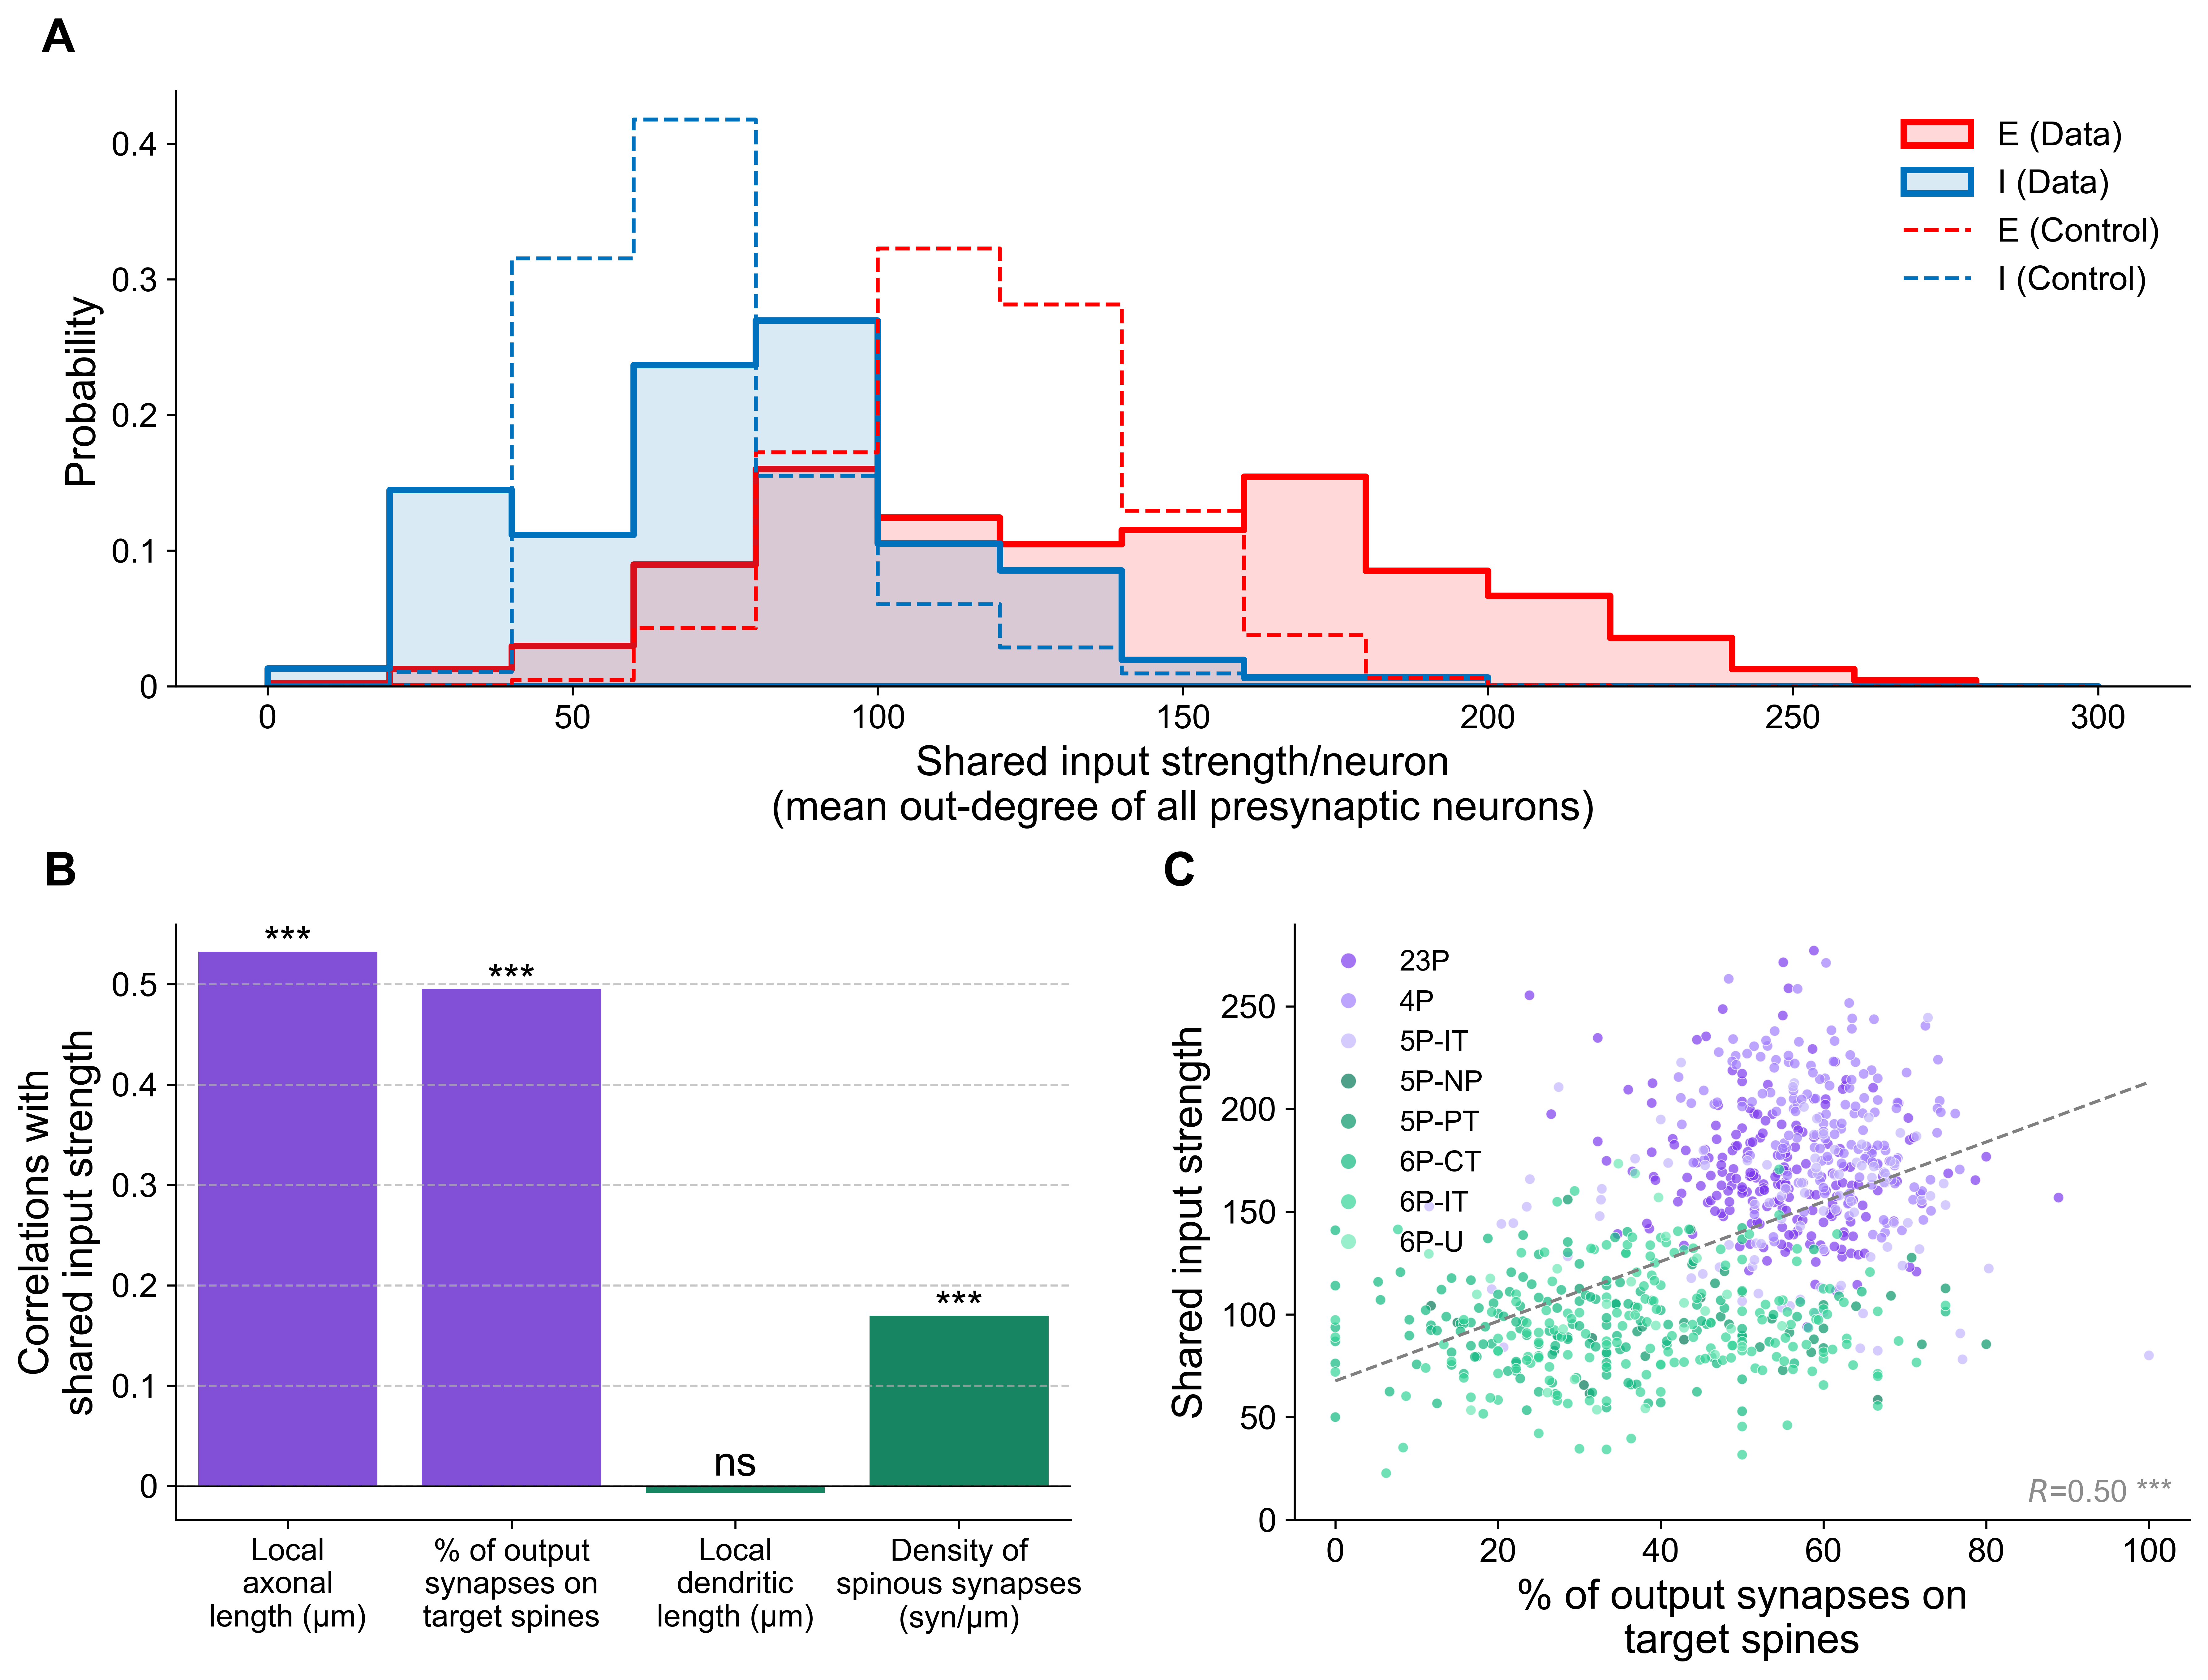

In [7]:
fig = plt.figure(figsize=(14, 10), dpi=600)
gs = fig.add_gridspec(2, 2, wspace=0.25, hspace=0.4)

ax_B = fig.add_subplot(gs[0, :])
ax_D = fig.add_subplot(gs[1, 0])
ax_E = fig.add_subplot(gs[1, 1])

shared_kwargs = dict(fill=True, alpha=0.15, stat='probability', element='step', linewidth=2.5)
control_kwargs = dict(fill=False, alpha=1, stat='probability', element='step', linestyle='--', linewidth=1.5)

sns.histplot(data=ex_od_df[sharing_feature], bins=dist_bins, color=ex_color, label=f'{e_label} (Data)', ax=ax_B, **shared_kwargs)
sns.histplot(data=inh_od_df[inh_sharing_feature], bins=dist_bins, color=inh_color, label=f'{i_label} (Data)', ax=ax_B, **shared_kwargs)
sns.histplot(data=e_control, bins=dist_bins, label=f'{e_label} (Control)', ax=ax_B, color=ex_color, **control_kwargs)
sns.histplot(data=i_control, bins=dist_bins, label=f'{i_label} (Control)', ax=ax_B, color=inh_color, **control_kwargs)
ax_B.set_ylabel('Probability')
ax_B.legend(frameon=False, loc='upper right')
ax_B.spines[['top', 'right']].set_visible(False)
ax_B.set_xlabel(sharing_prop_label)
ax_B.yaxis.set_major_formatter(FormatStrFormatter('%g'))

sns.barplot(x=x_feature_labels, y=pearson_corrs, ax=ax_D, palette=color_palette_bar_plot, hue=x_feature_labels, legend=False)
ax_D.set_ylabel(f'Correlations with\n{sharing_prop_label_short.lower()}')
ax_D.set_xticks(range(len(x_feature_labels)))
ax_D.set_xticklabels(x_feature_labels, fontsize=featues_small_font_size)
ax_D.axhline(0, color='black', linewidth=0.5)
ax_D.spines[['top', 'right']].set_visible(False)
ax_D.grid(axis='y', linestyle='--', alpha=0.7)
ax_D.yaxis.set_major_formatter(FormatStrFormatter('%g'))

for i, (corr, star) in enumerate(zip(pearson_corrs, pearson_corr_p_vals_str)):
    offset = 0.025
    y = corr + offset if corr >= 0 else offset + 0.015
    ax_D.text(x=i, y=y, s=star, ha='center', va='top', fontsize=16, color='black')

sns.scatterplot(data=ex_neurons_sorted, x=spine_pref_feature, y=sharing_feature, s=16, alpha=0.7, ax=ax_E,
                hue='cell_type', palette=scatter_palette, legend=True)
ax_E.legend(title='', loc='upper left', frameon=False, markerscale=1.5, fontsize=featues_small_font_size - 1, ncol=1)
ax_E.set_ylabel(sharing_prop_label_short)
ax_E.set_xlabel('% of output synapses on\ntarget spines')
ax_E.xaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0, symbol=''))
add_reg_line(ex_neurons[spine_pref_feature], ex_neurons[sharing_feature],
             ax=ax_E, color='gray', reg_text_font_size=reg_text_font_size,
             linestyle='--', linewidth=1.2, add_reg_text='r_only')
ax_E.spines[['top', 'right']].set_visible(False)
ax_E.set_ylim(bottom=0)

add_panel_label(ax_B, 'A', xy=(-0.05, 1.05))
add_panel_label(ax_D, 'B', xy=(-0.11, 1.05))
add_panel_label(ax_E, 'C', xy=(-0.11, 1.05))
plt.savefig('fig_s11.pdf', format='pdf', bbox_inches='tight')